In [1]:
# In[1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import traceback
import glob
import umap
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
import traceback
import ast
# --- Global Configuration & Setup ---
# This ensures all paths are correct, no matter where you run the notebook from.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Project Root set to: {PROJECT_ROOT}")

# Set a professional plot style
sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# === FIX FOR UMAP / SKLEARN 1.6 ISSUE   ===
# ==========================================
import sklearn.utils.validation

# Save the original check_array just in case
_original_check_array = sklearn.utils.validation.check_array

def _check_array_patch(*args, **kwargs):
    # Scikit-learn 1.6 strictness fix:
    # UMAP passes 'ensure_all_finite' which might be causing issues
    # or conflicting with positional args in the new version.
    # We simply pop it out to prevent the crash.
    if 'ensure_all_finite' in kwargs:
        kwargs.pop('ensure_all_finite')
    return _original_check_array(*args, **kwargs)

# Apply the patch to UMAP's internal reference
import umap.umap_
umap.umap_.check_array = _check_array_patch
# ==========================================

C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project Root set to: D:\Master thesis\github\master-thesis-trajectory-data-augmentation


In [2]:
class TrajectoryAnalyzer:
    def __init__(self, dataset_name, strategy_name, seed, model_type='rf', projection='umap'):
        """
        projection: 'umap' or 'pca'
        """
        print("="*80)
        print(f"INITIALIZING: {dataset_name} | {strategy_name} | {projection.upper()} | Seed={seed}")
        print("="*80)

        self.dataset_name = dataset_name
        self.strategy_name = strategy_name
        self.seed = seed
        self.model_type = model_type
        self.projection = projection.lower()

        self.best_params = {}
        self.best_suffix = ""

        self._find_optimal_params_and_load_data()
        self._prepare_data_for_ml()
        self._train_models_and_get_scores()

    def _find_optimal_params_and_load_data(self):
        print("\n[1/4] Finding optimal parameters from History...")
        history_dir = os.path.join(PROJECT_ROOT, 'data', 'output', 'optimization', 'history')
        search_pattern = os.path.join(history_dir, f'{self.dataset_name}_p*.csv')
        param_regex = re.compile(r'(_p\d+_n\d+_pp\d+)\.csv$')

        best_score = -1

        for f in glob.glob(search_pattern):
            match = param_regex.search(f)
            if not match: continue
            try:
                df = pd.read_csv(f)
                df['strategy_base'] = df['feature_type'].apply(lambda x: x.split('merged_')[-1].split('_p')[0] if 'merged' in str(x) else 'baseline')
                strat_df = df[df['strategy_base'] == self.strategy_name]
                if not strat_df.empty:
                    avg_score = strat_df['score'].mean()
                    if avg_score > best_score:
                        best_score = avg_score
                        self.best_suffix = match.group(1)
                        if 'params' in strat_df.columns:
                            try:
                                param_str = strat_df.iloc[0]['params']
                                if isinstance(param_str, str): self.best_params = ast.literal_eval(param_str)
                            except: pass
            except Exception: continue

        if not self.best_suffix:
            print(f"Warning: Using fallback file search.")
            aug_dir = os.path.join(PROJECT_ROOT, 'data', 'augmented', self.dataset_name, str(self.seed))
            files = glob.glob(os.path.join(aug_dir, f"*merged_{self.strategy_name}*.feather"))
            if files:
                m = re.search(r'(_p\d+_n\d+_pp\d+)', os.path.basename(files[0]))
                if m: self.best_suffix = m.group(1)

        print(f"✓ Target Suffix: {self.best_suffix}")

        base_path = os.path.join(PROJECT_ROOT, 'data', 'augmented', self.dataset_name, str(self.seed))
        self.df_train_orig = pd.read_feather(os.path.join(base_path, f"train_seed_{self.seed}_pts_trajectory_features.feather"))
        self.df_train_aug = pd.read_feather(os.path.join(base_path, f"train_seed_{self.seed}_pts_trajectory_features_merged_{self.strategy_name}{self.best_suffix}.feather"))
        self.df_test = pd.read_feather(os.path.join(base_path, f"test_seed_{self.seed}_pts_trajectory_features.feather"))

        self.tids_with_augs = self.df_train_aug[~self.df_train_aug['tid'].isin(self.df_train_orig['tid'])]['tid'].apply(lambda x: x.split('_')[0]).unique()

    def _prepare_data_for_ml(self):
        print("\n[2/4] Preparing Data...")
        common_cols = sorted(list(set(self.df_train_orig.columns) & set(self.df_test.columns) - {'tid', 'label'}))

        self.le = LabelEncoder()
        self.y_train_orig_enc = self.le.fit_transform(self.df_train_orig['label'])
        self.y_train_aug_enc = self.le.transform(self.df_train_aug['label'])
        self.y_test_enc = self.le.transform(self.df_test['label'])
        self.class_names = self.le.classes_

        scaler = StandardScaler()
        self.X_train_orig_scaled = scaler.fit_transform(self.df_train_orig[common_cols].fillna(0))
        self.X_train_aug_scaled = scaler.transform(self.df_train_aug[common_cols].fillna(0))
        self.X_test_scaled = scaler.transform(self.df_test[common_cols].fillna(0))

    def _get_model_instance(self):
        params = self.best_params.copy()
        if self.model_type == 'rf':
            if 'n_estimators' not in params: params['n_estimators'] = 100
            if 'random_state' not in params: params['random_state'] = 42
            return RandomForestClassifier(**params)
        elif self.model_type == 'mlp':
            if 'max_iter' not in params: params['max_iter'] = 500
            if 'random_state' not in params: params['random_state'] = 42
            return MLPClassifier(**params)
        else: return RandomForestClassifier(random_state=42)

    def _train_models_and_get_scores(self):
        print("\n[3/4] Training Models...")

        # A. TITLE SCORE
        print(f"   -> Training High-Dim {self.model_type.upper()} for Score...")
        self.real_model_orig = self._get_model_instance().fit(self.X_train_orig_scaled, self.y_train_orig_enc)
        self.real_model_aug = self._get_model_instance().fit(self.X_train_aug_scaled, self.y_train_aug_enc)

        y_pred_orig = self.real_model_orig.predict(self.X_test_scaled)
        y_pred_aug = self.real_model_aug.predict(self.X_test_scaled)

        self.f1_orig = f1_score(self.y_test_enc, y_pred_orig, average='weighted', zero_division=0)
        self.f1_aug = f1_score(self.y_test_enc, y_pred_aug, average='weighted', zero_division=0)
        self.f1_improvement = ((self.f1_aug - self.f1_orig) / self.f1_orig) * 100 if self.f1_orig > 0 else 0

        # B. VISUALIZATION PROJECTION
        print(f"   -> Calculating {self.projection.upper()} projection...")
        if self.projection == 'pca':
            self.reducer = PCA(n_components=2, random_state=42)
        else:
            self.reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42)

        self.X_train_orig_proj = self.reducer.fit_transform(self.X_train_orig_scaled)
        self.X_train_aug_proj = self.reducer.transform(self.X_train_aug_scaled)

        # C. BACKGROUND COLORS (KNN Painter)
        print("   -> Training KNN Painter for background...")
        self.viz_model_orig = KNeighborsClassifier(n_neighbors=30)
        self.viz_model_orig.fit(self.X_train_orig_proj, self.y_train_orig_enc)

        self.viz_model_aug = KNeighborsClassifier(n_neighbors=30)
        self.viz_model_aug.fit(self.X_train_aug_proj, self.y_train_aug_enc)

        print(f"✓ Success. {self.projection.upper()} generated.")

    def generate_master_plot(self, save_path=None):
        print("\n[4/4] Generating master visualization...")
        plt.style.use('dark_background')

        # Data Prep
        df_train_orig_proj = pd.DataFrame(self.X_train_orig_proj, columns=['dim1', 'dim2'])
        df_train_orig_proj['tid'] = self.df_train_orig['tid'].values
        df_train_orig_proj['label_enc'] = self.y_train_orig_enc
        df_train_orig_proj['type'] = 'Original (Not Selected)'
        df_train_orig_proj.loc[df_train_orig_proj['tid'].isin(self.tids_with_augs), 'type'] = 'Selected Original'

        df_train_aug_full_proj = pd.DataFrame(self.X_train_aug_proj, columns=['dim1', 'dim2'])
        df_train_aug_full_proj['tid'] = self.df_train_aug['tid'].values
        df_augmented_only_proj = df_train_aug_full_proj[~df_train_aug_full_proj['tid'].isin(df_train_orig_proj['tid'])].copy()

        if not df_augmented_only_proj.empty:
            aug_labels = self.df_train_aug[self.df_train_aug['tid'].isin(df_augmented_only_proj['tid'])]['label']
            df_augmented_only_proj['label_enc'] = self.le.transform(aug_labels)
            df_augmented_only_proj['parent_tid'] = df_augmented_only_proj['tid'].apply(lambda x: x.split('_')[0])

        # Colors
        n_classes = len(self.class_names)
        class_colors = sns.color_palette("tab10", n_colors=n_classes)
        cmap_explicit = ListedColormap(class_colors)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11))

        # Dynamic Bounds & Grid
        all_dim1 = np.concatenate([self.X_train_orig_proj[:,0], self.X_train_aug_proj[:,0]])
        all_dim2 = np.concatenate([self.X_train_orig_proj[:,1], self.X_train_aug_proj[:,1]])
        x_min, x_max = all_dim1.min(), all_dim1.max()
        y_min, y_max = all_dim2.min(), all_dim2.max()
        pad_x = (x_max - x_min) * 0.1
        pad_y = (y_max - y_min) * 0.1

        resolution = 400
        xx, yy = np.meshgrid(np.linspace(x_min - pad_x, x_max + pad_x, resolution),
                             np.linspace(y_min - pad_y, y_max + pad_y, resolution))

        # Plot 1
        ax1.set_title(f"Before Augmentation (Original Data)\n{self.model_type.upper()} F1-Score: {self.f1_orig:.4f}", fontsize=18)
        Z_orig = self.viz_model_orig.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax1.contourf(xx, yy, Z_orig, alpha=0.3, cmap=cmap_explicit)

        not_selected = df_train_orig_proj[df_train_orig_proj['type'] == 'Original (Not Selected)']
        selected = df_train_orig_proj[df_train_orig_proj['type'] == 'Selected Original']

        # Original (Circles)
        ax1.scatter(not_selected['dim1'], not_selected['dim2'], s=50, facecolors='none',
                    edgecolors=[class_colors[i] for i in not_selected['label_enc']], alpha=0.6, linewidth=1.5)
        # Selected (Stars)
        ax1.scatter(selected['dim1'], selected['dim2'], s=150, marker='*',
                    c=[class_colors[i] for i in selected['label_enc']], edgecolors='yellow', linewidth=0.8)

        # Plot 2
        ax2.set_title(f"After Augmentation\n{self.model_type.upper()} F1-Score: {self.f1_aug:.4f}", fontsize=18)
        Z_aug = self.viz_model_aug.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax2.contourf(xx, yy, Z_aug, alpha=0.3, cmap=cmap_explicit)

        ax2.scatter(not_selected['dim1'], not_selected['dim2'], s=50, facecolors='none',
                    edgecolors=[class_colors[i] for i in not_selected['label_enc']], alpha=0.6, linewidth=1.5)
        ax2.scatter(selected['dim1'], selected['dim2'], s=150, marker='*',
                    c=[class_colors[i] for i in selected['label_enc']], edgecolors='yellow', linewidth=0.8)

        if not df_augmented_only_proj.empty:
            ax2.scatter(df_augmented_only_proj['dim1'], df_augmented_only_proj['dim2'], s=60, marker='P',
                        c=[class_colors[i] for i in df_augmented_only_proj['label_enc']], edgecolors='k', linewidth=1)
            if not selected.empty:
                parents_proj = selected.set_index('tid')
                for _, child in df_augmented_only_proj.iterrows():
                    if child['parent_tid'] in parents_proj.index:
                        parent = parents_proj.loc[child['parent_tid']]
                        ax2.plot([parent['dim1'], child['dim1']], [parent['dim2'], child['dim2']],
                                 color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

        for ax in [ax1, ax2]:
            ax.set_xlabel(f"{self.projection.upper()} Dimension 1"); ax.set_ylabel(f"{self.projection.upper()} Dimension 2")
            ax.set_xlim(x_min - pad_x, x_max + pad_x); ax.set_ylim(y_min - pad_y, y_max + pad_y)

        legend_elements = []
        for i, class_name in enumerate(self.class_names):
            # 1. Original
            legend_elements.append(
                Line2D([0], [0], marker='o', color='w', label=f"Class '{class_name}' (Orig)",
                       markerfacecolor='none', markeredgecolor=class_colors[i],
                       markersize=10, markeredgewidth=1.5, linestyle='None') # <--- FIXED
            )
            # 2. Selected
            legend_elements.append(
                Line2D([0], [0], marker='*', color='w', label=f"Class '{class_name}' (Sel)",
                       markerfacecolor=class_colors[i], markeredgecolor='yellow',
                       markersize=15, markeredgewidth=0.8, linestyle='None') # <--- FIXED
            )
            # 3. Augmented
            legend_elements.append(
                Line2D([0], [0], marker='P', color='w', label=f"Class '{class_name}' (Aug)",
                       markerfacecolor=class_colors[i], markeredgecolor='k',
                       markersize=10, markeredgewidth=1.0, linestyle='None') # <--- FIXED
            )
            # 4. Region
            legend_elements.append(
                Patch(facecolor=class_colors[i], alpha=0.3, edgecolor='none',
                      label=f"Region '{class_name}'")
            )

        n_rows = len(self.class_names)
        # Increased margin slightly more to prevent title overlap
        bottom_margin_req = 0.12 + (n_rows * 0.035)

        # Rect: [left, bottom, right, top] -> Limited top to 0.9 to give title space
        plt.tight_layout(rect=[0, bottom_margin_req, 1, 0.85])

        fig.legend(handles=legend_elements,
                   loc='lower center',
                   ncol=4,
                   bbox_to_anchor=(0.5, 0.02),
                   fontsize=14,
                   frameon=True,
                   edgecolor='gray',
                   columnspacing=1.2,
                   handletextpad=0.5)

        title_string = (f"Visual Analysis ({self.projection.upper()})\n"
                        f"Dataset: {self.dataset_name.title()} | Strategy: {self.strategy_name.title()} | Seed: {self.seed}\n"
                        f"Final F1-Score Improvement ({self.model_type.upper()}): {self.f1_improvement:+.2f}%")
        fig.suptitle(title_string, fontsize=24, y=0.98) # Lowered title slightly

        if save_path:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
            plt.close(fig)
            print(f"✓ Success: Plot saved to {save_path}")
        else:
            plt.show()
        plt.style.use('default')

INITIALIZING: foxes | outlierness | UMAP | Seed=1415

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p40_n3_pp40

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...


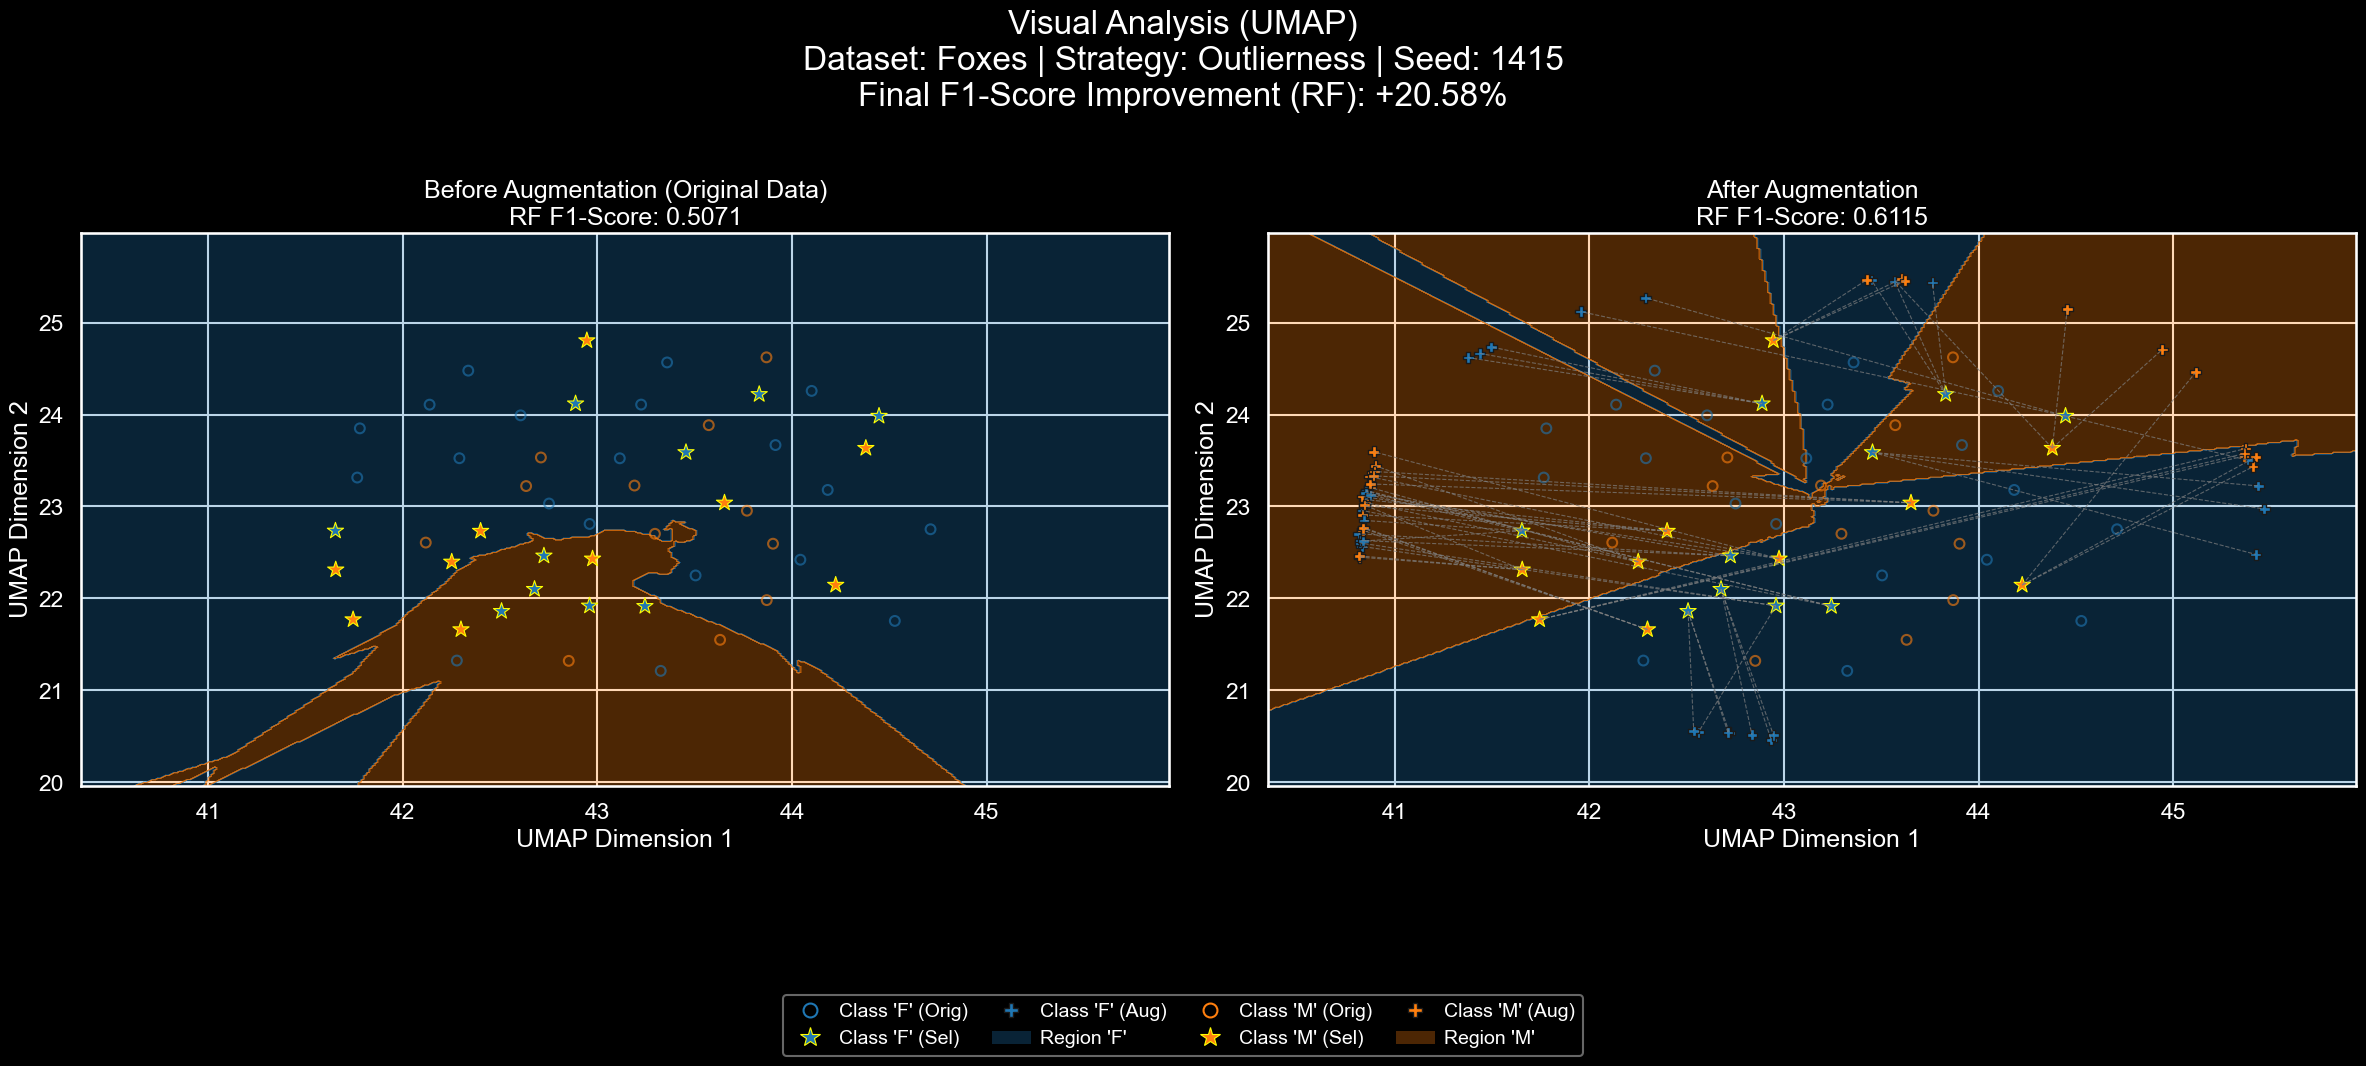

In [3]:
# In[3]:
# ===================================================================
# ==                     INTERACTIVE ANALYSIS                      ==
# ===================================================================
# --- Simply change these values to analyze a different scenario ---

CONFIG = {
    "dataset": 'foxes',        # Options: 'foxes', 'car_traffic', 'starkey', 'ais_subset'
    "strategy": 'outlierness', # Options: 'outlierness', 'random', 'diversity', 'representativeness', 'uncertainty'
    "seed": 1415,               # Options: Any seed from your PI_SEEDS list
    "model_type": "rf",
    "projection": "pca" # Change to 'pca' to see the difference
}

# --- Then, run this cell to generate the full analysis plot ---
try:
    analyzer = TrajectoryAnalyzer(
        dataset_name=CONFIG["dataset"],
        strategy_name=CONFIG["strategy"],
        seed=CONFIG["seed"]
    )
    analyzer.generate_master_plot() # Call with no arguments to show the plot inline

except Exception as e:
    print("\n" + "!"*80)
    print("--- ANALYSIS FAILED ---")
    print(f"Error: {e}")
    print("\nIMPORTANT: This usually means you haven't run the main pipeline for this combination yet.")
    print(f"Please run 'python main.py --datasets {CONFIG['dataset']}' to generate the necessary files.")
    print("--- Full Traceback ---")
    traceback.print_exc()
    print("!"*80)

In [4]:
# %%
# In[4]:
# ===================================================================
# ==          BATCH MODE: GENERATE AND SAVE ALL IMAGES             ==
# ===================================================================
import traceback
import glob # Needed for finding existing files

# --- Colorama Setup ---
try:
    import colorama
    colorama.init(autoreset=True)
    GREEN, RED, YELLOW, RESET = colorama.Fore.GREEN, colorama.Fore.RED, colorama.Fore.YELLOW, colorama.Style.RESET_ALL
except ImportError:
    GREEN = RED = YELLOW = RESET = ""

# --- Configuration ---
DATASETS_TO_PROCESS = ['foxes', 'starkey', 'ais_subset', 'car_traffic']
STRATEGIES_TO_PROCESS = ['outlierness', 'random', 'diversity', 'representativeness', 'uncertainty']

PI_SEEDS = [1415, 9265, 3589, 7932, 3846, 2643, 3832, 7950, 2884, 1971,
            6939, 9375, 1058, 2097, 4944, 5923, 781, 6406, 2862, 899]
SEEDS_TO_PROCESS = PI_SEEDS

BASE_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'output', 'analysis', 'visual_analysis')

# --- Main Loop ---
jobs = [{'dataset': d, 'strategy': s, 'seed': seed}
        for d in DATASETS_TO_PROCESS
        for s in STRATEGIES_TO_PROCESS
        for seed in SEEDS_TO_PROCESS]

print(f"Starting batch job. Total combinations to check: {len(jobs)}")
failed_jobs = []
skipped_count = 0
processed_count = 0

for i, job in enumerate(jobs):
    dataset, strategy, seed = job['dataset'], job['strategy'], job['seed']
    job_desc = f"JOB {i+1}/{len(jobs)}: {dataset} | {strategy} | {seed}"

    # 1. Define the directory for this specific seed
    seed_dir = os.path.join(BASE_OUTPUT_DIR, dataset, str(seed))
    os.makedirs(seed_dir, exist_ok=True)

    # 2. Check if ANY file for this strategy already exists (ignoring the score part)
    #    We look for: strategy_*.png
    existing_files = glob.glob(os.path.join(seed_dir, f"{strategy}_*.png"))

    if existing_files:
        print(f"SKIPPING: Found {os.path.basename(existing_files[0])}")
        skipped_count += 1
        continue

    print("\n" + "-"*80)
    print(f"--- STARTING {job_desc} ---")

    try:
        # 3. Run the Analyzer
        #    Note: Default projection is 'umap'. Change here if you want pca.
        analyzer = TrajectoryAnalyzer(
            dataset_name=dataset,
            strategy_name=strategy,
            seed=seed,
            model_type='rf',       # Ensure this matches your thesis model
            projection='umap'      # 'umap' or 'pca'
        )

        # 4. Construct Filename with F1 Improvement
        #    Format: strategy_(+10.50%).png
        score_str = f"{analyzer.f1_improvement:+.2f}%"
        filename = f"{strategy}_({score_str}).png"
        output_path = os.path.join(seed_dir, filename)

        # 5. Generate and Save
        analyzer.generate_master_plot(save_path=output_path)
        print(f"{GREEN}Saved: {filename}{RESET}")
        processed_count += 1

    except FileNotFoundError as e:
        error_message = f"SKIPPING: Required data file not found. Details: {e}"
        print(f"{YELLOW}{error_message}{RESET}")
        # Don't add to failed_jobs if it's just missing data (common in dev)
    except Exception as e:
        error_traceback = traceback.format_exc()
        print(f"{RED}{'!'*80}{RESET}")
        print(f"{RED}FATAL ERROR in job: {job_desc}{RESET}")
        print(f"{RED}{e}{RESET}")
        print(error_traceback)
        print(f"{RED}{'!'*80}{RESET}")
        failed_jobs.append({'job': job, 'error': str(e)})

# --- Summary ---
print("\n\n" + "="*80)
print("BATCH PROCESSING COMPLETE!")
print(f"Generated: {processed_count}")
print(f"Skipped:   {skipped_count}")
print(f"Failed:    {len(failed_jobs)}")

if failed_jobs:
    print("\n--- FAILED JOBS ---")
    for failure in failed_jobs:
        print(f"  - {failure['job']} -> {failure['error']}")
else:
    print(f"\n{GREEN}All Clear!{RESET}")

Starting batch job. Total combinations to check: 400

--------------------------------------------------------------------------------
--- STARTING JOB 1/400: foxes | outlierness | 1415 ---
INITIALIZING: foxes | outlierness | UMAP | Seed=1415

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p40_n3_pp40

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\github\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\foxes\1415\outlierness_(+20.58%).png
Saved: outlierness_(+20.58%).png

--------------------------------------------------------------------------------
--- STARTING JOB 2/400: foxes | outlierness | 9265 ---
INITIALIZING: foxes | outlierness | UMAP | Seed=9265

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p40_n3_pp40

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\github\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\foxes\9265\outlierness_(-17.82%).png
Saved: outlierness_(-17.82%).png

--------------------------------------------------------------------------------
--- STARTING JOB 3/400: foxes | outlierness | 3589 ---
INITIALIZING: foxes | outlierness | UMAP | Seed=3589

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p40_n3_pp40

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


...

   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\github\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\car_traffic\6406\uncertainty_(+0.00%).png
Saved: uncertainty_(+0.00%).png

--------------------------------------------------------------------------------
--- STARTING JOB 399/400: car_traffic | uncertainty | 2862 ---
INITIALIZING: car_traffic | uncertainty | UMAP | Seed=2862

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p20_n1_pp10

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\github\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\car_traffic\2862\uncertainty_(+0.00%).png
Saved: uncertainty_(+0.00%).png

--------------------------------------------------------------------------------
--- STARTING JOB 400/400: car_traffic | uncertainty | 899 ---
INITIALIZING: car_traffic | uncertainty | UMAP | Seed=899

[1/4] Finding optimal parameters from History...
✓ Target Suffix: _p20_n1_pp10

[2/4] Preparing Data...

[3/4] Training Models...
   -> Training High-Dim RF for Score...
   -> Calculating UMAP projection...


C:\Users\adamn\OneDrive\Skrivbord\Master Thesis\clean\master-thesis-trajectory-data-augmentation\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   -> Training KNN Painter for background...
✓ Success. UMAP generated.

[4/4] Generating master visualization...
✓ Success: Plot saved to D:\Master thesis\github\master-thesis-trajectory-data-augmentation\data\output\analysis\visual_analysis\car_traffic\899\uncertainty_(+0.00%).png
Saved: uncertainty_(+0.00%).png


BATCH PROCESSING COMPLETE!
Generated: 400
Skipped:   0
Failed:    0

All Clear!
